Изображение сохранено как: image.png


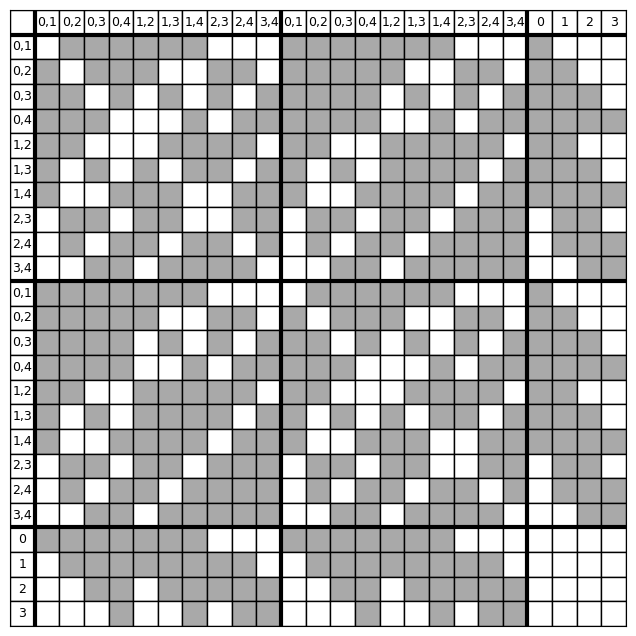

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


def draw_grid(matrix, save_path=None, dpi=500, text_positions=None, font_size=12, N = 5):
    """
    Рисует квадратную сетку на основе матрицы из 0 и 1.

    Args:
        matrix: двумерный список или numpy-массив из 0 и 1
        save_path: путь для сохранения файла (например, 'image.png')
        dpi: разрешение сохраняемого изображения (по умолчанию 300)
        text_positions: словарь с текстом и координатами {(строка, столбец): 'текст', ...}
        font_size: размер шрифта (по умолчанию 12)
    """
    # Преобразуем в numpy массив для удобства
    grid = np.array(matrix)
    n, m = grid.shape

    # Создаем фигуру
    fig, ax = plt.subplots(figsize=(8, 8))

    # Рисуем сетку
    # Проходим по всем клеткам
    for i in range(n):
        for j in range(m):
            if grid[i, j] == 1:
                # Закрашенная клетка (черный цвет)
                color = 'darkgray'
                # Рисуем прямоугольник
                rect = plt.Rectangle((j, n - 1 - i), 1, 1, facecolor=color, edgecolor='black', linewidth=1)
                ax.add_patch(rect)
            else:
                # Пустая клетка (белая, но с рамкой)
                rect = plt.Rectangle((j, n - 1 - i), 1, 1, facecolor='white', edgecolor='black', linewidth=1)
                ax.add_patch(rect)

    plt.axvline(x=1, color='black', linewidth=3)
    plt.axvline(x=N * (N - 1) / 2 + 1, color='black', linewidth=3)
    plt.axvline(x=N * (N - 1) + 1, color='black', linewidth=3)
    plt.axhline(y=n - 1, color='black', linewidth=3)
    plt.axhline(y=n - N * (N - 1) / 2 - 1, color='black', linewidth=3)
    plt.axhline(y=n - N * (N - 1) - 1, color='black', linewidth=3)

    # Добавляем текст в указанные клетки
    if text_positions:
        for (row, col), text in text_positions.items():
            # Преобразуем координаты матрицы в координаты графика
            x = col + 0.5  # Центр клетки по X
            y = n - 1 - row + 0.5  # Центр клетки по Y

            # Определяем цвет текста в зависимости от цвета клетки
            text_color = 'black'  # На белом фоне - черный текст

            # Добавляем текст
            ax.text(x, y, text, ha='center', va='center',
                   fontsize=font_size, color=text_color, fontweight='normal')

    # Настраиваем оси
    ax.set_xlim(0, m)
    ax.set_ylim(0, n)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(True, which='both', color='black', linewidth=0.5)
    ax.set_xticklabels([])
    ax.set_yticklabels([])

    # Сохраняем изображение, если указан путь
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight',
                   facecolor='white', pad_inches=0.1)
        print(f"Изображение сохранено как: {save_path}")

    # Показываем изображение
    plt.show()

def GetMatrixFromFile(N):
    arr = []
    #filename = f'd_tensor_file{N}.txt'
    filename = f'f_tensor_file{N}.txt'
    with open(filename, 'r') as file:
        for line in file:
            # Пропускаем пустые строки
            line = line.strip()
            if not line:
                continue

            # Разделяем строку на части
            parts = line.split()
            if len(parts) >= 2:
                a, b = int(parts[0]), int(parts[1])
                arr.append((a, b))

    return arr


def main(N):
    matrix = np.zeros((N * N, N * N))
    arr = GetMatrixFromFile(N)
    for (one, two) in arr:
        matrix[one + 1][two + 1] = 1


    # Задаем текст для разных клеток
    # Формат: (строка, столбец): 'текст'
    # Нумерация строк и столбцов начинается с 0
    text_positions = dict()

    i = 0
    j = 1

    ind = 1
    for i in range(0, N - 1):
        for j in range(i + 1, N):
            text_positions[(0, ind)] = f"{i},{j}"
            text_positions[(0, N * (N - 1) / 2 + ind)] = f"{i},{j}"
            text_positions[(ind, 0)] = f"{i},{j}"
            text_positions[(N * (N - 1) / 2 + ind, 0)] = f"{i},{j}"
            ind += 1

    for l in range(0, N - 1):
        text_positions[(0, N * (N - 1) + 1 + l)] = f"{l}"
        text_positions[(N * (N - 1) + l + 1, 0)] = f"{l}"




    # Рисуем и сохраняем
    draw_grid(matrix, save_path='image.png', text_positions=text_positions, font_size=9, N = N)


main(5)

Изображение сохранено как: image.png


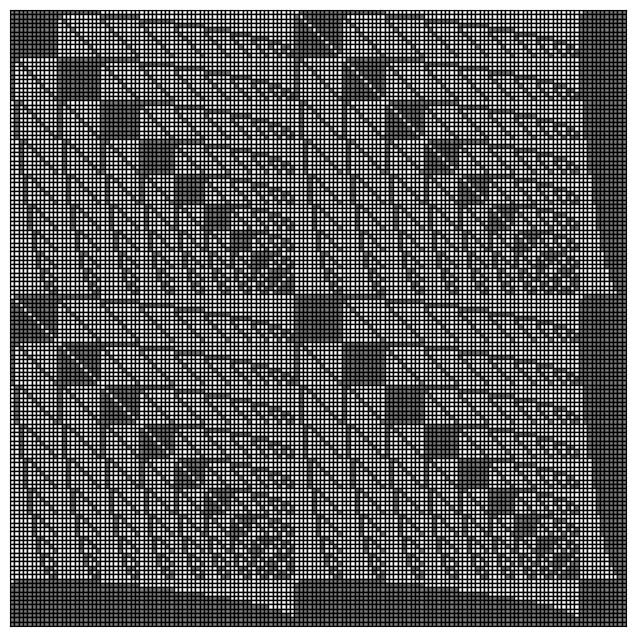

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.pyplot as plt
import numpy as np

def draw_color_grid(matrix, save_path=None, dpi=500, text_positions=None, font_size=12):
    """
    Рисует квадратную сетку на основе матрицы из 0 и 1.

    Args:
        matrix: двумерный список или numpy-массив из 0 и 1
        save_path: путь для сохранения файла (например, 'image.png')
        dpi: разрешение сохраняемого изображения (по умолчанию 300)
        text_positions: словарь с текстом и координатами {(строка, столбец): 'текст', ...}
        font_size: размер шрифта (по умолчанию 12)
    """
    # Преобразуем в numpy массив для удобства
    grid = np.array(matrix)
    n, m = grid.shape
    max_value = np.max(grid)

    # Создаем фигуру
    fig, ax = plt.subplots(figsize=(8, 8))

    # Выбираем цветовую карту (colormap)
    # Варианты: 'coolwarm', 'viridis', 'plasma', 'RdYlBu', 'Blues', 'Reds'
    cmap = plt.cm.coolwarm

    # Рисуем сетку
    # Проходим по всем клеткам
    for i in range(n):
        for j in range(m):
            if grid[i, j] != 0:
                normalized = (grid[i, j] - 1) / (max_value - 1)
                color = 'gray'
                #color = cmap(normalized)
                # Рисуем прямоугольник
                rect = plt.Rectangle((j, n - 1 - i), 1, 1, facecolor=color, edgecolor='black', linewidth=1)
                ax.add_patch(rect)
            else:
                # Пустая клетка (белая, но с рамкой)
                rect = plt.Rectangle((j, n - 1 - i), 1, 1, facecolor='white', edgecolor='black', linewidth=1)
                ax.add_patch(rect)

    # Настраиваем оси
    ax.set_xlim(0, m)
    ax.set_ylim(0, n)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(True, which='both', color='black', linewidth=0.5)
    #ax.set_xticklabels([])
    #ax.set_yticklabels([])

    # Сохраняем изображение, если указан путь
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight',
                   facecolor='white', pad_inches=0.1)
        print(f"Изображение сохранено как: {save_path}")

    # Показываем изображение
    plt.show()

def GetMatrixFromFile(N: int):
    arr = []
    filename = f'd_tensor_file{N}.txt'
    #filename = f'f_tensor_file{N}.txt'
    with open(filename, 'r') as file:
        for line in file:
            # Пропускаем пустые строки
            line = line.strip()
            if not line:
                continue

            # Разделяем строку на части
            parts = line.split()
            if len(parts) >= 2:
                a, b, c = int(parts[0]), int(parts[1]), int(parts[2])
                arr.append((a, b, c))

    return arr

def main(N: int):
    matrix = np.zeros((N * N - 1, N * N - 1))
    arr = GetMatrixFromFile(N)
    for (one, two, three) in arr:
        matrix[one][two] += 1


    # Рисуем и сохраняем
    draw_color_grid(matrix, save_path='image.png', text_positions=None, font_size=24)


main(12)

Изображение сохранено как: tensor.png


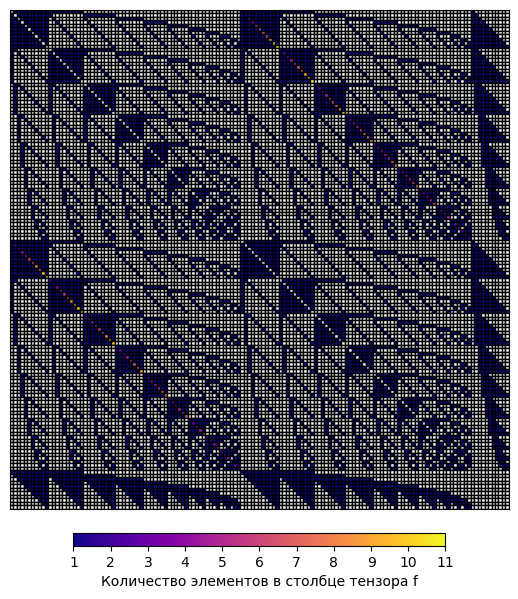

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np


def draw_color_grid(matrix, save_path=None, dpi=500):
    """
    Рисует квадратную сетку на основе матрицы из 0 и 1.

    Args:
        matrix: двумерный список или numpy-массив из 0 и 1
        save_path: путь для сохранения файла (например, 'image.png')
        dpi: разрешение сохраняемого изображения (по умолчанию 300)
    """
    # Преобразуем в numpy массив для удобства
    grid = np.array(matrix)
    n, m = grid.shape
    max_value = np.max(grid)

    # Создаем фигуру
    fig, ax = plt.subplots(figsize=(8, 8))

    # Выбираем цветовую карту (colormap)
    # Варианты: 'coolwarm', 'viridis', 'plasma', 'RdYlBu', 'Blues', 'Reds'
    cmap = plt.cm.plasma
    # colors = [(0.6, 0.6, 0.6), (0, 0, 0)]  # можно указать больше промежуточных цветов
    # cmap = LinearSegmentedColormap.from_list('gray_to_black', colors, N=max_value)


    # Рисуем сетку
    # Проходим по всем клеткам
    for i in range(n):
        for j in range(m):
            if grid[i, j] != 0:
                normalized = (grid[i, j] - 1) / (max_value - 1)
                color = cmap(normalized)
                #color = 'gray'
                # Рисуем прямоугольник
                rect = plt.Rectangle((j, n - 1 - i), 1, 1, facecolor=color, edgecolor='black', linewidth=1)
                ax.add_patch(rect)
            else:
                # Пустая клетка (белая, но с рамкой)
                rect = plt.Rectangle((j, n - 1 - i), 1, 1, facecolor='white', edgecolor='black', linewidth=1)
                ax.add_patch(rect)

    # Настраиваем оси
    ax.set_xlim(0, m)
    ax.set_ylim(0, n)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(True, which='both', color='black', linewidth=0.5)
    #ax.set_xticklabels([])
    #ax.set_yticklabels([])


    # ========== ДОБАВЛЯЕМ ЛЕГЕНДУ (COLORBAR) ==========
    # Создаём ScalarMappable для привязки colorbar к нашей цветовой карте
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=1, vmax=max_value))
    sm.set_array(range(1, int(max_value) + 1))  # нужно для colorbar

    # Добавляем colorbar справа от сетки
    cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', shrink=0.6, aspect=30, pad=0.04,
                        ticks=np.arange(1, int(max_value) + 1))
    cbar.set_label('Количество элементов в столбце тензора f', fontsize=10)
    cbar.ax.tick_params(labelsize=10)
    # ====================================================

    # Сохраняем изображение, если указан путь
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight',
                   facecolor='white', pad_inches=0.1)
        print(f"Изображение сохранено как: {save_path}")

    # Показываем изображение
    plt.show()

def GetMatrixFromFile(N: int):
    arr = []
    #filename = f'd_tensor_file{N}.txt'
    filename = f'f_tensor_file{N}.txt'
    with open(filename, 'r') as file:
        for line in file:
            # Пропускаем пустые строки
            line = line.strip()
            if not line:
                continue

            # Разделяем строку на части
            parts = line.split()
            if len(parts) >= 2:
                a, b, c = int(parts[0]), int(parts[1]), int(parts[2])
                arr.append((a, b, c))

    return arr

def main(N: int):
    matrix = np.zeros((N * N - 1, N * N - 1))
    arr = GetMatrixFromFile(N)
    for (one, two, three) in arr:
        matrix[one][two] += 1


    # Рисуем и сохраняем
    draw_color_grid(matrix, save_path='tensor.png')


main(12)

Изображение сохранено как: image.png


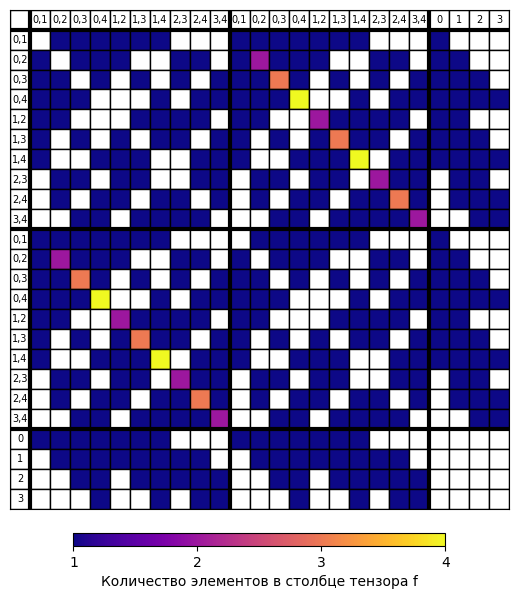

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


def draw_grid(matrix, save_path=None, dpi=500, text_positions=None, font_size=12, N = 5):
    """
    Рисует квадратную сетку на основе матрицы из 0 и 1.

    Args:
        matrix: двумерный список или numpy-массив из 0 и 1
        save_path: путь для сохранения файла (например, 'image.png')
        dpi: разрешение сохраняемого изображения (по умолчанию 300)
        text_positions: словарь с текстом и координатами {(строка, столбец): 'текст', ...}
        font_size: размер шрифта (по умолчанию 12)
    """
    # Преобразуем в numpy массив для удобства
    grid = np.array(matrix)
    n, m = grid.shape
    max_value = np.max(grid)
    cmap = plt.cm.plasma

    # Создаем фигуру
    fig, ax = plt.subplots(figsize=(8, 8))

    # Рисуем сетку
    # Проходим по всем клеткам
    for i in range(n):
        for j in range(m):
            if grid[i, j] != 0:

                normalized = (grid[i, j] - 1) / (max_value - 1)
                color = cmap(normalized)

                rect = plt.Rectangle((j, n - 1 - i), 1, 1, facecolor=color, edgecolor='black', linewidth=1)
                ax.add_patch(rect)
            else:
                # Пустая клетка (белая, но с рамкой)
                rect = plt.Rectangle((j, n - 1 - i), 1, 1, facecolor='white', edgecolor='black', linewidth=1)
                ax.add_patch(rect)

    plt.axvline(x=1, color='black', linewidth=3)
    plt.axvline(x=N * (N - 1) / 2 + 1, color='black', linewidth=3)
    plt.axvline(x=N * (N - 1) + 1, color='black', linewidth=3)
    plt.axhline(y=n - 1, color='black', linewidth=3)
    plt.axhline(y=n - N * (N - 1) / 2 - 1, color='black', linewidth=3)
    plt.axhline(y=n - N * (N - 1) - 1, color='black', linewidth=3)

    # Добавляем текст в указанные клетки
    if text_positions:
        for (row, col), text in text_positions.items():
            # Преобразуем координаты матрицы в координаты графика
            x = col + 0.5  # Центр клетки по X
            y = n - 1 - row + 0.5  # Центр клетки по Y

            # Определяем цвет текста в зависимости от цвета клетки
            text_color = 'black'  # На белом фоне - черный текст

            # Добавляем текст
            ax.text(x, y, text, ha='center', va='center',
                   fontsize=font_size, color=text_color, fontweight='normal')

    # Настраиваем оси
    ax.set_xlim(0, m)
    ax.set_ylim(0, n)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(True, which='both', color='black', linewidth=0.5)
    ax.set_xticklabels([])
    ax.set_yticklabels([])

    # ========== ДОБАВЛЯЕМ ЛЕГЕНДУ (COLORBAR) ==========
    # Создаём ScalarMappable для привязки colorbar к нашей цветовой карте
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=1, vmax=max_value))
    sm.set_array(range(1, int(max_value) + 1))  # нужно для colorbar

    # Добавляем colorbar справа от сетки
    cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', shrink=0.6, aspect=30, pad=0.04,
                        ticks=np.arange(1, int(max_value) + 1))
    cbar.set_label('Количество элементов в столбце тензора f', fontsize=10)
    cbar.ax.tick_params(labelsize=10)
    # ====================================================


    # Сохраняем изображение, если указан путь
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight',
                   facecolor='white', pad_inches=0.1)
        print(f"Изображение сохранено как: {save_path}")

    # Показываем изображение
    plt.show()

def GetMatrixFromFile(N):
    arr = []
    #filename = f'd_tensor_file{N}.txt'
    filename = f'f_tensor_file{N}.txt'
    with open(filename, 'r') as file:
        for line in file:
            # Пропускаем пустые строки
            line = line.strip()
            if not line:
                continue

            # Разделяем строку на части
            parts = line.split()
            if len(parts) >= 2:
                a, b = int(parts[0]), int(parts[1])
                arr.append((a, b))

    return arr


def main(N):
    matrix = np.zeros((N * N, N * N))
    arr = GetMatrixFromFile(N)
    for (one, two) in arr:
        matrix[one + 1][two + 1] += 1


    # Задаем текст для разных клеток
    # Формат: (строка, столбец): 'текст'
    # Нумерация строк и столбцов начинается с 0
    text_positions = dict()

    i = 0
    j = 1

    ind = 1
    for i in range(0, N - 1):
        for j in range(i + 1, N):
            text_positions[(0, ind)] = f"{i},{j}"
            text_positions[(0, N * (N - 1) / 2 + ind)] = f"{i},{j}"
            text_positions[(ind, 0)] = f"{i},{j}"
            text_positions[(N * (N - 1) / 2 + ind, 0)] = f"{i},{j}"
            ind += 1

    for l in range(0, N - 1):
        text_positions[(0, N * (N - 1) + 1 + l)] = f"{l}"
        text_positions[(N * (N - 1) + l + 1, 0)] = f"{l}"




    # Рисуем и сохраняем
    draw_grid(matrix, save_path='image.png', text_positions=text_positions, font_size=7, N = N)


main(5)

Изображение сохранено как: tensor.png


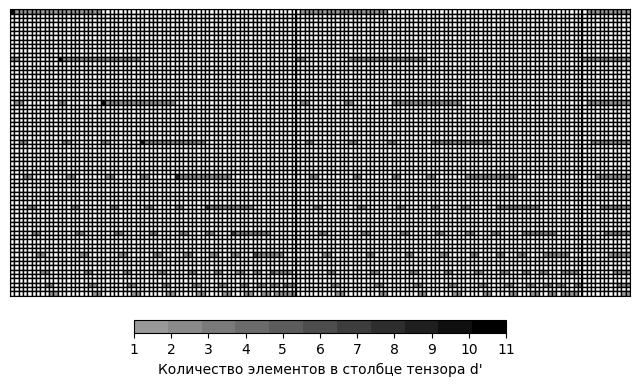

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np


def draw_color_grid(matrix, N: int, save_path=None, dpi=500):
    """
    Рисует квадратную сетку на основе матрицы из 0 и 1.

    Args:
        matrix: двумерный список или numpy-массив из 0 и 1
        save_path: путь для сохранения файла (например, 'image.png')
        dpi: разрешение сохраняемого изображения (по умолчанию 300)
    """
    # Преобразуем в numpy массив для удобства
    grid = np.array(matrix)
    n, m = grid.shape
    max_value = np.max(grid)

    # Создаем фигуру
    fig, ax = plt.subplots(figsize=(8, 8))

    # Выбираем цветовую карту (colormap)
    # Варианты: 'coolwarm', 'viridis', 'plasma', 'RdYlBu', 'Blues', 'Reds'
    # cmap = plt.cm.spring
    colors = [(0.6, 0.6, 0.6), (0, 0, 0)]  # можно указать больше промежуточных цветов
    cmap = LinearSegmentedColormap.from_list('gray_to_black', colors, N=max_value)


    # Рисуем сетку
    # Проходим по всем клеткам
    for i in range(n):
        for j in range(m):
            if grid[i, j] != 0:
                normalized = (grid[i, j] - 1) / (max_value - 1)
                color = cmap(normalized)
                #color = 'gray'
                # Рисуем прямоугольник
                rect = plt.Rectangle((j, n - 1 - i), 1, 1, facecolor=color, edgecolor='black', linewidth=1)
                ax.add_patch(rect)
            else:
                # Пустая клетка (белая, но с рамкой)
                rect = plt.Rectangle((j, n - 1 - i), 1, 1, facecolor='white', edgecolor='black', linewidth=1)
                ax.add_patch(rect)

    plt.axvline(x=N * (N - 1) / 2, color='black', linewidth=1.5)
    plt.axvline(x=N * (N - 1), color='black', linewidth=1.5)

    # Настраиваем оси
    ax.set_xlim(0, m)
    ax.set_ylim(0, n)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(True, which='both', color='black', linewidth=0.5)
    #ax.set_xticklabels([])
    #ax.set_yticklabels([])

    # ========== ДОБАВЛЯЕМ ЛЕГЕНДУ (COLORBAR) ==========
    # Создаём ScalarMappable для привязки colorbar к нашей цветовой карте
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=1, vmax=max_value))
    sm.set_array(range(1, int(max_value) + 1))  # нужно для colorbar

    # Добавляем colorbar справа от сетки
    cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', shrink=0.6, aspect=30, pad=0.04,
                        ticks=np.arange(1, int(max_value) + 1))
    cbar.set_label('Количество элементов в столбце тензора d\'', fontsize=10)
    cbar.ax.tick_params(labelsize=10)
    # ====================================================

    # Сохраняем изображение, если указан путь
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight',
                   facecolor='white', pad_inches=0.1)
        print(f"Изображение сохранено как: {save_path}")

    # Показываем изображение
    plt.show()

def GetMatrixFromFile(N: int):
    arr = []
    filename = f'd_tensor_file{N}.txt'
    #filename = f'f_tensor_file{N}.txt'
    with open(filename, 'r') as file:
        for line in file:
            # Пропускаем пустые строки
            line = line.strip()
            if not line:
                continue

            # Разделяем строку на части
            parts = line.split()
            if len(parts) >= 2:
                a, b, c = int(parts[0]), int(parts[1]), int(parts[2])
                arr.append((a, b, c))

    return arr

def Mapping(i: int, j: int, N: int):
    return i * (N - 1) - (i * (i - 1)) // 2 + j - i - 1;


def main(N: int):
    matrix = np.zeros((N * (N - 1) // 2, N * N - 1))
    arr = GetMatrixFromFile(N)

    check_arr = np.zeros(N * N - 1)

    for i in range(N - 1):  # i from 0 to N-2
        idx = Mapping(i, i + 1, N)
        check_arr[idx] = 1

    for (one, two, three) in arr:
        if(one <= N * (N - 1) // 2 and check_arr[one] == 1):
            matrix[one][two] += 1


    # Рисуем и сохраняем
    draw_color_grid(matrix, N, save_path='tensor.png')


main(12)